Primero se realizan los imports

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

## Carga y limpieza de los datos

In [96]:
data = pd.read_csv("Data_2025/pib2020-2025.csv")
data.head(5)

,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
2,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
3,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
4,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0


In [97]:
# (1.1) Carga de datos y exploración inicial
pibData = pd.read_csv('Data_2025/pib2020-2025.csv')
lifeData = pd.read_csv('Data_2025/WHO_life_expectancy.csv')

pibData.head(), lifeData.head()

(       Country    2020      2021      2022      2023      2024      2025
 0  Afghanistan   20136   14278.0   14501.0   17248.0       NaN       NaN
 1      Albania   15271   18086.0   19185.0   23388.0   27259.0   28372.0
 2      Algeria  164774  185850.0  225709.0  247789.0  264913.0  268885.0
 3      Andorra    2885    3325.0    3376.0    3786.0    4038.0    4035.0
 4       Angola   66521   84375.0  142442.0  109764.0  115946.0  113343.0,
    IndicatorCode                         Indicator ParentLocationCode  \
 0  WHOSIS_000001  Life expectancy at birth (years)                AFR   
 1  WHOSIS_000001  Life expectancy at birth (years)                AFR   
 2  WHOSIS_000001  Life expectancy at birth (years)                AFR   
 3  WHOSIS_000001  Life expectancy at birth (years)                AFR   
 4  WHOSIS_000001  Life expectancy at birth (years)                EMR   
 
           ParentLocation Location type SpatialDimValueCode  \
 0                 Africa       Country       

In [98]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  196 non-null    object 
 1   2020     196 non-null    int64  
 2   2021     194 non-null    float64
 3   2022     194 non-null    float64
 4   2023     194 non-null    float64
 5   2024     192 non-null    float64
 6   2025     189 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 10.8+ KB


### Se cambia el tipo de dato

In [99]:
data["Country"] = data["Country"].astype("string")

### Se revisa si hay datos nulos

In [100]:
data.isnull().sum()
#Vemos que hay pocos datos nulos asi que los reemplazamos por el promedio del pais

Country    0
2020       0
2021       2
2022       2
2023       2
2024       4
2025       7
dtype: int64

### Rellenamos los datos nulos con el promedio de sus respectivos paises

In [101]:
pid = data.copy()
años_columnas = ["2020", "2021", "2022", "2023", "2024", "2025"]

pid[años_columnas] = pid[años_columnas].apply(pd.to_numeric, errors='coerce')

for i, fila in pid.iterrows():
    vals = fila[años_columnas].astype("float64")   
    promedio_pais = vals.mean(skipna=True)
    pid.loc[i, años_columnas] = vals.fillna(promedio_pais).to_numpy()

pid.isnull().sum()

Country    0
2020       0
2021       0
2022       0
2023       0
2024       0
2025       0
dtype: int64

### Creamos una nueva columna con el porcentaje de crecimiento del PIB

In [102]:
pib_long = pid.melt(id_vars='Country',
                        value_vars=años_columnas,
                        var_name='Year',
                        value_name='GDP')
pib_long['Year'] = pib_long['Year'].astype(int)
pib_long = pib_long.sort_values(['Country', 'Year'])

pib_long['growth_rate'] = (
    pib_long.groupby('Country')['GDP']
            .pct_change() * 100
)

pib_long.head()


,Country,Year,GDP,growth_rate
0,Afghanistan,2020,20136.00,NaN
196,Afghanistan,2021,14278.00,-29.092173
392,Afghanistan,2022,14501.00,1.561843
588,Afghanistan,2023,17248.00,18.943521
784,Afghanistan,2024,16540.75,-4.100475


### Calculamos la media, mediana y desviación estandar del PIB para 3 paises

In [103]:
paises = ["Chile", "Argentina", "Peru"]
stats_pib = (pib_long[pib_long["Country"].isin(paises)]
            .groupby("Country")["GDP"]
            .agg(["mean", "median", "std"]))
stats_pib

,mean,median,std
Country,,,
Argentina,577460.833333,632231.5,115928.316022
Chile,313400.166667,322810.5,32785.945705
Peru,256165.500000,255950.5,37240.162829


In [104]:
growth_stats = (pib_long[pib_long['Country'].isin(paises)]
                .groupby('Country')['growth_rate']
                .agg(['mean','std','min','max']))
growth_stats


,mean,std,min,max
Country,,,,
Argentina,12.882716,14.454018,-2.070608,30.095877
Chile,6.715493,11.482607,-4.483357,24.148233
Peru,8.008483,1.876904,4.920262,9.593579


### Visualización y comparacion de PIB

Creamos un gráfico de líneas que muestre la 

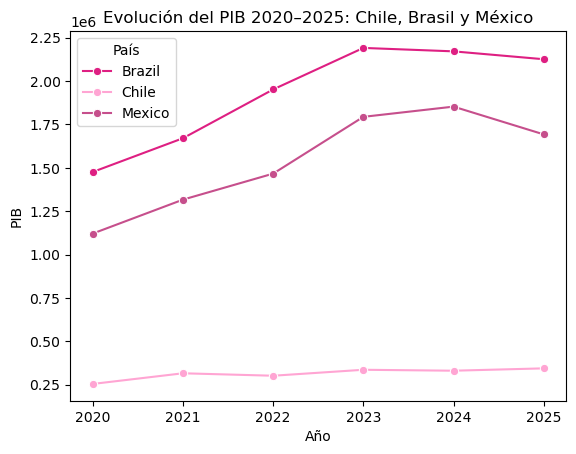

In [105]:
paises3 = ["Chile", "Brazil", "Mexico"]
sub = pib_long[pib_long["Country"].isin(paises3)]
colores = {"#DE1F82","#C64F8C", "#FFA5D3"}
plt.figure()
sns.lineplot(data=sub, x="Year", y="GDP", hue="Country", marker="o", palette=colores)
plt.title("Evolución del PIB 2020–2025: Chile, Brasil y México")
plt.xlabel("Año")
plt.ylabel("PIB")
plt.legend(title="País")
plt.show()


<Figure size 640x480 with 0 Axes>

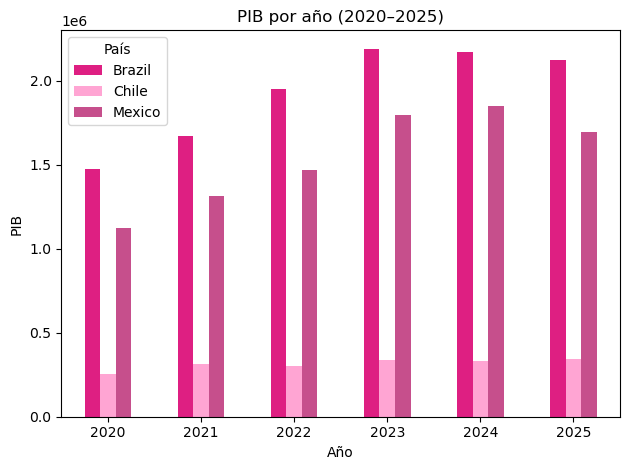

In [106]:
pivot_pib = sub.pivot(index="Year", columns="Country", values="GDP")
colores = {"#DE1F82","#C64F8C", "#FFA5D3"}
plt.figure()
pivot_pib.plot(kind="bar", color=colores)
plt.title("PIB por año (2020–2025)")
plt.xlabel("Año")
plt.ylabel("PIB")
plt.xticks(rotation=0)
plt.legend(title="País")
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

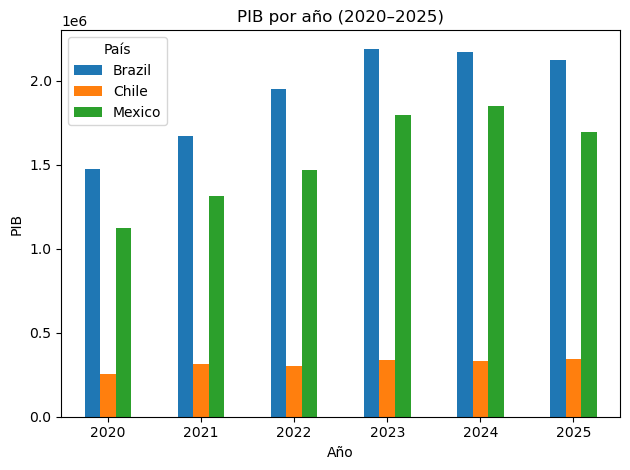

In [107]:
pivot_pib = sub.pivot(index="Year", columns="Country", values="GDP")

plt.figure()
pivot_pib.plot(kind="bar")
plt.title("PIB por año (2020–2025)")
plt.xlabel("Año")
plt.ylabel("PIB")
plt.xticks(rotation=0)
plt.legend(title="País")
plt.tight_layout()
plt.show()


### (c) Interpretación (5 pts)

Indica qué país muestra el **mayor crecimiento acumulado** en el periodo 2020–2025 y justifica tu respuesta basándote en los gráficos y/o cálculos realizados.


In [108]:
pivot_pib
growth_2020_2025 = (pivot_pib.loc[2025] - pivot_pib.loc[2020]) / pivot_pib.loc[2020] * 100
growth_2020_2025


Country
Brazil    44.026118
Chile     35.331418
Mexico    50.985001
dtype: float64

# Pregunta 3 — Análisis de Salud Global (25 puntos)

En esta pregunta utilizarás el dataset `WHO_life_expectancy.csv`, que contiene datos de esperanza de vida para distintos países.

---

### (a) Carga y filtrado (5 pts)

Carga el dataset y filtra solo los países: **Chile, Japón, Nigeria, Estados Unidos e India**.


In [109]:
life = pd.read_csv("Data_2025/WHO_life_expectancy.csv")

life_filt = life[life["Dim1"] == "Both sexes"].copy()
paises5 = ["Chile", "Japan", "Nigeria", "India", "United States of America"]
life_filt = life_filt[life_filt["Location"].isin(paises5)].copy()

def extract_value(s):
    if isinstance(s, str):
        try:
            return float(s.split(" ")[0])
        except:
            return np.nan
    return np.nan

life_filt["LifeExpectancy"] = life_filt["Value"].apply(extract_value)
life_filt = life_filt.dropna(subset=["LifeExpectancy"])
life_filt[["Location", "Period", "LifeExpectancy"]].head()


,Location,Period,LifeExpectancy
90,Nigeria,2021,63.4
169,India,2021,67.3
406,United States of America,2021,76.4
462,Chile,2021,79.0
546,Japan,2021,84.5


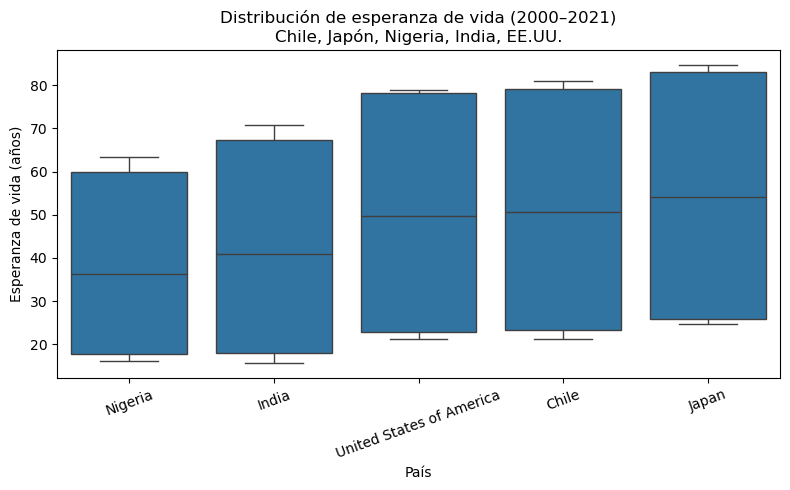

In [110]:
plt.figure(figsize=(8,5))
sns.boxplot(data=life_filt, x="Location", y="LifeExpectancy")
plt.title("Distribución de esperanza de vida (2000–2021)\nChile, Japón, Nigeria, India, EE.UU.")
plt.xlabel("País")
plt.ylabel("Esperanza de vida (años)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### (c) Cómputo e interpretación (10 pts)

Calcula para cada país:
- media,
- mediana,
- mínimo,
- máximo  

de la esperanza de vida.  
Escribe un comentario explicando **dos observaciones relevantes** comparando países más desarrollados vs. en desarrollo.


In [111]:
stats_life = (life_filt
            .groupby("Location")["LifeExpectancy"]
            .agg(["count","mean","median","min","max"]))
stats_life


,count,mean,median,min,max
Location,,,,,
Chile,44,51.047727,50.70,21.3,81.0
India,44,42.602273,40.85,15.6,70.7
Japan,44,54.525000,54.20,24.6,84.7
Nigeria,44,38.468182,36.35,16.2,63.4
United States of America,44,50.227273,49.80,21.3,78.8


# Pregunta 4 — Integración de Datos (25 puntos)

En esta pregunta combinarás ambos datasets: `pib2020-2025.csv` y `WHO_life_expectancy.csv`.

---

### (a) Preparación (5 pts)

Toma el PIB del año **2023** y la esperanza de vida del año **2023** del otro dataset.  
Filtra para que ambos incluyan los **mismos países**.


In [112]:

gdp_2023 = pid[["Country", "2023"]].rename(columns={"2023": "gdp_2023"})
gdp_2023.head()


,Country,gdp_2023
0,Afghanistan,17248.0
1,Albania,23388.0
2,Algeria,247789.0
3,Andorra,3786.0
4,Angola,109764.0


### (b) Merge (5 pts)

Realiza un `merge` por país para obtener una tabla combinada con las columnas:

- `country`
- `gdp_2023`
- `life_exp_2023`


In [113]:
life_2021 = life[(life["Dim1"] == "Both sexes") &
                (life["Period"] == 2021) &
                (life["Indicator"] == "Life expectancy at birth (years)")].copy()

life_2021["life_exp_2021"] = life_2021["Value"].apply(extract_value)
life_2021 = life_2021[["Location","life_exp_2021"]].rename(columns={"Location":"Country"})
life_2021.head()


,Country,life_exp_2021
2,Lesotho,51.5
5,Central African Republic,52.3
6,Somalia,54.0
8,Eswatini,54.6
18,Mozambique,57.7


In [114]:
combo = pd.merge(gdp_2023, life_2021, on="Country", how="inner")
combo.shape
combo.head()


,Country,gdp_2023,life_exp_2021
0,Afghanistan,17248.0,59.1
1,Albania,23388.0,76.4
2,Algeria,247789.0,76.0
3,Angola,109764.0,62.1
4,Antigua and Barbuda,2006.0,76.9


### (c) Gráfico de dispersión (10 pts)

Construye un **gráfico de dispersión** donde:

- eje X = PIB 2023 (`gdp_2023`)  
- eje Y = esperanza de vida 2023 (`life_exp_2023`)  

Agrega, si lo consideras pertinente, una recta de tendencia.


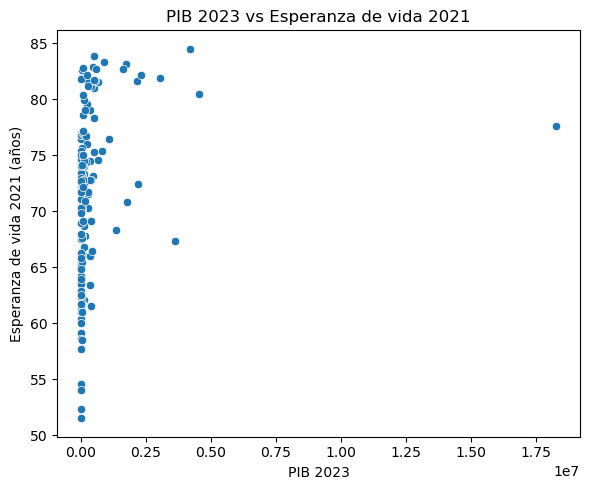

,gdp_2023,life_exp_2021
gdp_2023,1.000000,0.218686
life_exp_2021,0.218686,1.000000


In [115]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=combo, x="gdp_2023", y="life_exp_2021")
plt.title("PIB 2023 vs Esperanza de vida 2021")
plt.xlabel("PIB 2023")
plt.ylabel("Esperanza de vida 2021 (años)")
plt.tight_layout()
plt.show()

combo[["gdp_2023","life_exp_2021"]].corr()


### (*3 pts*) 1.1 Carga inicial de datos

Cargue los datos de los archivos `pib2020-2025.csv` y `WHO_life_expectancy.csv` en dos DataFrames llamados `pibData` y `lifeData`, respectivamente.

Muestre las primeras filas de cada DataFrame y comente brevemente (2–3 líneas) sobre su estructura: número de filas, columnas y tipos de datos más relevantes.


In [116]:
# (1.1) Carga de datos y exploración inicial
pibData = pd.read_csv('Data_2025/pib2020-2025.csv')
lifeData = pd.read_csv('Data_2025/WHO_life_expectancy.csv')

pibData.head(), lifeData.head()

(       Country    2020      2021      2022      2023      2024      2025
 0  Afghanistan   20136   14278.0   14501.0   17248.0       NaN       NaN
 1      Albania   15271   18086.0   19185.0   23388.0   27259.0   28372.0
 2      Algeria  164774  185850.0  225709.0  247789.0  264913.0  268885.0
 3      Andorra    2885    3325.0    3376.0    3786.0    4038.0    4035.0
 4       Angola   66521   84375.0  142442.0  109764.0  115946.0  113343.0,
    IndicatorCode                         Indicator ParentLocationCode  \
 0  WHOSIS_000001  Life expectancy at birth (years)                AFR   
 1  WHOSIS_000001  Life expectancy at birth (years)                AFR   
 2  WHOSIS_000001  Life expectancy at birth (years)                AFR   
 3  WHOSIS_000001  Life expectancy at birth (years)                AFR   
 4  WHOSIS_000001  Life expectancy at birth (years)                EMR   
 
           ParentLocation Location type SpatialDimValueCode  \
 0                 Africa       Country       

### (*5 pts*) 1.2 Transformación de la base de PIB

A partir de `pibData`, genere un nuevo DataFrame llamado `pibLong` que tenga el formato “largo”, con las siguientes columnas:

- `Country`: nombre del país.  
- `Year`: año (como entero).  
- `GDP`: valor del PIB para ese país y año.

Considere solo los años entre **2020 y 2023**. Elimine las filas donde el valor de PIB sea nulo.


In [117]:
# (1.2) Transformación wide → long para PIB
# Ajuste la lista de columnas de años según corresponda
year_cols = [c for c in pibData.columns if c.isdigit()]

pibLong = (
    pibData
    .melt(id_vars='Country', value_vars=year_cols,
        var_name='Year', value_name='GDP')
)

# Conversión de Year a entero y eliminación de nulos
pibLong['Year'] = pibLong['Year'].astype(int)
pibLong = pibLong.dropna(subset=['GDP'])

pibLong.head()

,Country,Year,GDP
0,Afghanistan,2020,20136.0
1,Albania,2020,15271.0
2,Algeria,2020,164774.0
3,Andorra,2020,2885.0
4,Angola,2020,66521.0


### (1.3) Limpieza de la base de esperanza de vida  (*7 pts*)

Prepare un DataFrame llamado `lifeClean` con las siguientes características:

* Considere solo las filas donde `Dim1` sea **"Both sexes"** (o equivalente en el archivo).  
* Considere únicamente el indicador de **esperanza de vida al nacer (años)** (ajuste según la columna que identifique el indicador si es necesario).  
* Renombre columnas para trabajar de forma homogénea:
  * `Location` → `Country`  
  * `Period` → `Year`
* La columna `Value` suele tener un texto del tipo `"72.5 [71.3-73.6]"`.  
  Extraiga el número inicial (antes del espacio) y conviértalo a un valor numérico (float) en una nueva columna `LifeExpectancy`.

Elimine las filas donde `LifeExpectancy` no se pueda interpretar numéricamente o sea nula.


In [118]:
# (1.3) Limpieza y transformación de la base de esperanza de vida

lifeClean = lifeData.copy()

# Filtrado de 'Both sexes' si la columna Dim1 existe
if 'Dim1' in lifeClean.columns:
    lifeClean = lifeClean[lifeClean['Dim1'] == 'Both sexes']

# Renombrar columnas principales si existen
rename_map = {}
if 'Location' in lifeClean.columns:
    rename_map['Location'] = 'Country'
if 'Period' in lifeClean.columns:
    rename_map['Period'] = 'Year'
lifeClean = lifeClean.rename(columns=rename_map)

# Extraer valor numérico de la columna 'Value'
def extract_value(x):
    if isinstance(x, str):
        try:
            return float(x.split(' ')[0])
        except:
            return np.nan
    return np.nan

lifeClean['LifeExpectancy'] = lifeClean['Value'].apply(extract_value)
lifeClean = lifeClean.dropna(subset=['LifeExpectancy'])

# Asegurarse de que Year sea entero si existe
if 'Year' in lifeClean.columns:
    lifeClean['Year'] = lifeClean['Year'].astype(int)

lifeClean.head()

,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Country,Period type,Year,Dim1 type,Dim1,Value,LifeExpectancy
2,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,LSO,Lesotho,Year,2021,Sex,Both sexes,51.5 [50.5-52.6],51.5
5,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,CAF,Central African Republic,Year,2021,Sex,Both sexes,52.3 [51.1-53.4],52.3
6,WHOSIS_000001,Life expectancy at birth (years),EMR,Eastern Mediterranean,Country,SOM,Somalia,Year,2021,Sex,Both sexes,54.0 [52.9-55.1],54.0
8,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,SWZ,Eswatini,Year,2021,Sex,Both sexes,54.6 [53.5-55.9],54.6
18,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,MOZ,Mozambique,Year,2021,Sex,Both sexes,57.7 [56.6-58.8],57.7


### (1.4) Selección de países en común  (*4 pts*)

Para evitar problemas de nombres distintos entre bases de datos, trabajaremos solo con los países que aparecen **en ambas**.

1. Obtenga el conjunto de países de `pibLong` y de `lifeClean`.  
2. Calcule la intersección de ambos conjuntos.  
3. Genere dos DataFrames filtrados:
   * `pibCommon`: subconjunto de `pibLong` con solo los países en común.  
   * `lifeCommon`: subconjunto de `lifeClean` con solo los países en común.


In [119]:
# (1.4) Filtrado de países en común entre ambas bases

pib_countries = set(pibLong['Country'].unique())
life_countries = set(lifeClean['Country'].unique())

common_countries = pib_countries.intersection(life_countries)
len(common_countries), list(sorted(common_countries))[:10]  # muestra algunos

pibCommon = pibLong[pibLong['Country'].isin(common_countries)].copy()
lifeCommon = lifeClean[lifeClean['Country'].isin(common_countries)].copy()

pibCommon.head(), lifeCommon.head()

(               Country  Year       GDP
 0          Afghanistan  2020   20136.0
 1              Albania  2020   15271.0
 2              Algeria  2020  164774.0
 4               Angola  2020   66521.0
 5  Antigua and Barbuda  2020    1412.0,
     IndicatorCode                         Indicator ParentLocationCode  \
 2   WHOSIS_000001  Life expectancy at birth (years)                AFR   
 5   WHOSIS_000001  Life expectancy at birth (years)                AFR   
 6   WHOSIS_000001  Life expectancy at birth (years)                EMR   
 8   WHOSIS_000001  Life expectancy at birth (years)                AFR   
 18  WHOSIS_000001  Life expectancy at birth (years)                AFR   
 
            ParentLocation Location type SpatialDimValueCode  \
 2                  Africa       Country                 LSO   
 5                  Africa       Country                 CAF   
 6   Eastern Mediterranean       Country                 SOM   
 8                  Africa       Country           

### (1.5) Base consolidada `socioData`  (*4 pts*)

Usando `pibCommon` y `lifeCommon`, construya un DataFrame consolidado llamado `socioData` que contenga, para cada combinación país–año:

* `Country`  
* `Year`  
* `GDP`  
* `LifeExpectancy`  

Para ello, realice un `merge` adecuado entre ambas bases sobre las columnas `Country` y `Year`.

Verifique que:

* No existan filas duplicadas por combinación `Country`–`Year`.  
* No existan valores nulos en `GDP` ni en `LifeExpectancy`.

En caso de encontrarlos, explique brevemente cómo los maneja (eliminar filas, imputar, etc.).


In [120]:
# (1.5) Construcción de la base consolidada socioData

socioData = pd.merge(
    pibCommon,
    lifeCommon[['Country', 'Year', 'LifeExpectancy']],
    on=['Country', 'Year'],
    how='inner'
)

# Verificar duplicados
dup_mask = socioData.duplicated(subset=['Country', 'Year'], keep=False)
socioData[dup_mask].head()

# Eliminar filas con nulos en las variables clave
socioData = socioData.dropna(subset=['GDP', 'LifeExpectancy'])

socioData.head(), socioData.shape

(       Country  Year       GDP  LifeExpectancy
 0  Afghanistan  2020   20136.0            60.5
 1  Afghanistan  2020   20136.0            13.8
 2      Albania  2020   15271.0            76.5
 3      Albania  2020   15271.0            19.7
 4      Algeria  2020  164774.0            74.0,
 (642, 4))

---
## 2. Análisis exploratorio de datos (EDA)  (25 pts)

En esta sección exploraremos la relación entre el PIB y la esperanza de vida usando la base consolidada `socioData`.


### (2.1) Año de referencia  (*5 pts*)

Para hacer comparaciones claras entre países, trabajaremos con un año fijo.

1. Verifique qué años están disponibles en la columna `Year` de `socioData`.  
2. Seleccione el año **2023** si está disponible; en caso contrario, seleccione el año más reciente disponible.  
3. Genere un DataFrame `socioRef` que contenga solo las observaciones de ese año seleccionado.

Muestre cuántos países hay en `socioRef` y las primeras filas.


In [121]:
# (2.1) Selección de año de referencia

available_years = sorted(socioData['Year'].unique())
print('Años disponibles en socioData:', available_years)

ref_year = 2023 if 2023 in available_years else max(available_years)
print('Año de referencia seleccionado:', ref_year)

socioRef = socioData[socioData['Year'] == ref_year].copy()
socioRef.shape, socioRef.head()

Años disponibles en socioData: [np.int64(2020), np.int64(2021)]
Año de referencia seleccionado: 2021


((320, 4),
          Country  Year       GDP  LifeExpectancy
 322  Afghanistan  2021   14278.0            59.1
 323  Afghanistan  2021   14278.0            13.7
 324      Albania  2021   18086.0            76.4
 325      Albania  2021   18086.0            19.9
 326      Algeria  2021  185850.0            76.0)

### (2.2) Correlación y visualización básica  (*10 pts*)

Sobre el DataFrame `socioRef`:

1. Genere una **matriz de correlación** que incluya al menos las variables `GDP` y `LifeExpectancy`. Muéstrela como un **heatmap**.  
2. Construya un **diagrama de dispersión (scatterplot)** con:
   * eje X = `GDP`  
   * eje Y = `LifeExpectancy`  

   Si lo considera adecuado, puede usar escala logarítmica para el eje X.

Comente brevemente (3–4 líneas) qué tipo de relación parece observarse entre estas variables.


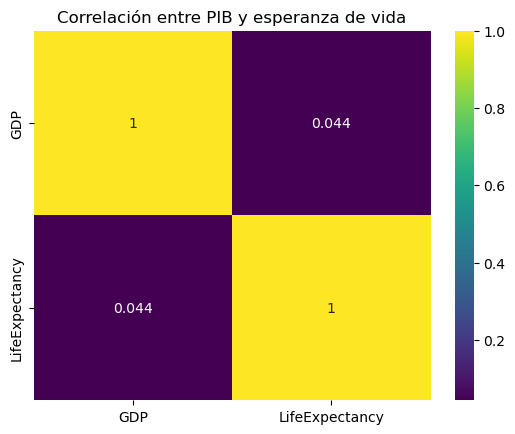

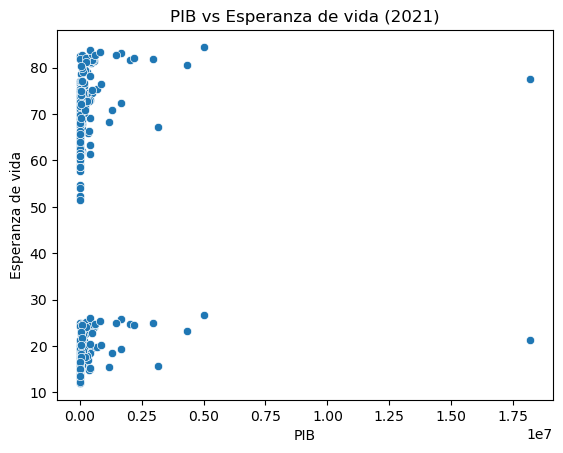

In [122]:
# (2.2) Heatmap de correlación y scatterplot

corr = socioRef[['GDP', 'LifeExpectancy']].corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap='viridis')
plt.title('Correlación entre PIB y esperanza de vida')
plt.show()

plt.figure()
sns.scatterplot(data=socioRef, x='GDP', y='LifeExpectancy')
plt.title(f'PIB vs Esperanza de vida ({ref_year})')
plt.xlabel('PIB')
plt.ylabel('Esperanza de vida')
plt.show()

### (2.3) Comparación entre países extremos  (*10 pts*)

Usando `socioRef`:

1. Ordene los países de mayor a menor según `GDP`.  
2. Muestre una tabla con los **5 países con mayor PIB** y otra con los **5 países con menor PIB** (si hay suficientes países).  
3. Compare los niveles de `LifeExpectancy` entre estos grupos.

Escriba un comentario (3–5 líneas) indicando si los países con mayor PIB presentan sistemáticamente una mayor esperanza de vida que los de menor PIB.


In [123]:
# (2.3) Comparación de países según PIB

socioRef_sorted = socioRef.sort_values('GDP', ascending=False)

top5 = socioRef_sorted.head(5)
bottom5 = socioRef_sorted.tail(5)

top5, bottom5

(     Country  Year         GDP  LifeExpectancy
 385    China  2021  18190803.0            21.2
 384    China  2021  18190803.0            77.6
 469    Japan  2021   5039148.0            26.6
 468    Japan  2021   5039148.0            84.5
 430  Germany  2021   4351188.0            80.5,
       Country  Year    GDP  LifeExpectancy
 567     Samoa  2021  844.0            17.7
 617     Tonga  2021  520.0            18.9
 616     Tonga  2021  520.0            72.7
 476  Kiribati  2021  285.0            60.9
 477  Kiribati  2021  285.0            14.1)

---
## 3. Modelando la relación entre PIB y esperanza de vida  (30 pts)

En esta sección utilizaremos modelos de regresión para estudiar la relación entre el PIB de un país y su esperanza de vida, usando todos los años disponibles en `socioData`.


### (3.1) Preparación de los datos para modelar  (*8 pts*)

Trabajaremos con todas las filas de `socioData`.

1. Defina como variable dependiente `y` la columna `LifeExpectancy`.  
2. Como variable independiente principal, utilizaremos el PIB:
   * Cree una nueva columna `log_GDP = log(GDP)` para estabilizar la escala.  
3. Use como predictores al menos:
   * `log_GDP`  
   * `Year`  

4. Divida los datos en conjuntos de **entrenamiento** y **prueba**, usando una proporción cercana a 75%/25%.  
   Puede utilizar funciones de la librería `sklearn` si fue vista en clases, o construir el split manualmente.

Muestre el tamaño de cada conjunto.


In [124]:
# (3.1) Preparación de datos para modelar

import math
from sklearn.model_selection import train_test_split

socioData = socioData.copy()
socioData['log_GDP'] = np.log(socioData['GDP'])

X = socioData[['log_GDP', 'Year']]
y = socioData['LifeExpectancy']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_train.shape, X_test.shape

((481, 2), (161, 2))

### (3.2) Regresión lineal múltiple  (*10 pts*)

Entrene un modelo de **regresión lineal múltiple** usando los predictores `log_GDP` y `Year`.

1. Ajuste el modelo con el conjunto de entrenamiento.  
2. Calcule el **RMSE** (error cuadrático medio raíz) y el **R²** en los conjuntos de entrenamiento y prueba.  
3. Comente si el modelo captura razonablemente bien la relación entre PIB, año y esperanza de vida.

> Puede usar `LinearRegression` de `sklearn` u otra herramienta vista en el curso.


In [125]:
# (3.2) Modelo de regresión lineal múltiple

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_train_pred = linreg.predict(X_train)
y_test_pred = linreg.predict(X_test)

rmse_train = math.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = math.sqrt(mean_squared_error(y_test, y_test_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

rmse_train, rmse_test, r2_train, r2_test

(26.54977121599325,
 27.324456373758665,
 0.011100952249783802,
 -0.0030957399247519835)

### (3.3) Extensión del modelo y discusión  (*12 pts*)

Considere ahora extender el modelo incorporando alguna transformación adicional o interacción, por ejemplo:

* Un término cuadrático sobre `log_GDP` (`(log_GDP)^2`).  
* Una interacción entre `log_GDP` y `Year`.  

1. Construya un nuevo set de predictores agregando al menos una de estas extensiones.  
2. Entrene un nuevo modelo de regresión lineal con estos predictores extendidos.  
3. Calcule nuevamente RMSE y R² en entrenamiento y prueba.  
4. Compare los resultados del modelo extendido con el modelo de la parte (3.2).

Responda en 4–5 líneas:

* ¿Mejora la calidad del ajuste al agregar estos términos?  
* ¿Observa riesgo de sobreajuste?  
* ¿Qué modelo preferiría usar para interpretar la relación entre PIB y esperanza de vida?


In [126]:
# (3.3) Modelo extendido con término cuadrático e interacción

X_ext = X.copy()
X_ext['log_GDP_sq'] = X_ext['log_GDP']**2
X_ext['log_GDP_Year'] = X_ext['log_GDP'] * X_ext['Year']

X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    X_ext, y, test_size=0.25, random_state=42
)

linreg_ext = LinearRegression()
linreg_ext.fit(X_train_ext, y_train_ext)

y_train_pred_ext = linreg_ext.predict(X_train_ext)
y_test_pred_ext = linreg_ext.predict(X_test_ext)

rmse_train_ext = math.sqrt(mean_squared_error(y_train_ext, y_train_pred_ext))
rmse_test_ext = math.sqrt(mean_squared_error(y_test_ext, y_test_pred_ext))
r2_train_ext = r2_score(y_train_ext, y_train_pred_ext)
r2_test_ext = r2_score(y_test_ext, y_test_pred_ext)

rmse_train_ext, rmse_test_ext, r2_train_ext, r2_test_ext

(26.545731725749405,
 27.339512283554825,
 0.011401847058594594,
 -0.0042014658394187165)

### Preguntas Tipo Tareas


## 3. Carga y limpieza (1 punto)

### 3.1 DataFrame unificado (0.2 pts)

Inspeccione los atributos de cada dataset y extraiga la siguiente información de ellos:

1. Información de las montañas:
    * ID de la cima (`peakid`)
    * Nombre común de la montaña (`pkname`)
    * Altura (m) (`heightm`)
    * Cantidad de expediciones exitosas (`success_exp`)
    * Cantidad de expediciones fallidas (`failed_exp`)

2. Información de las expediciones:
    * ID de la expedición (`expid`)
    * Año (`year`)
    * Estación del año (`season`)

3. Información de los montañistas:
    * ID del miembro (`memid`)
    * Sexo (`sex`)
    * Año de nacimiento (`yob`)
    * Nacionalidad (`citizen`)
    * Completó la expedición exitosamente (`msuccess`)

Genere un único DataFrame con todos estos atributos, donde cada fila represente el ascenso de un/a montañista en una expedición. (Ojo que esto no necesariamente significa que cada fila será una persona diferente: si una persona escaló dos cumbres distintas en dos expediciones, esta debería aparecer en su DataFrame como dos filas separadas.)


In [ ]:
#Abrimos los csv (en exped, members me aparecia una advertencia por los tipos de datos, como los que me daban eran numero, los pase a string altiro)
df_exped = pd.read_csv("Himalayan+Expeditions/exped.csv", dtype={8: str, 18: str, 19: str})
df_members = pd.read_csv("Himalayan+Expeditions/members.csv", dtype={34: str})
df_peaks = pd.read_csv("Himalayan+Expeditions/peaks.csv")
df_peaks_with = pd.read_csv("Himalayan+Expeditions/peaks_with_exp.csv", encoding="latin1")

In [ ]:
members_columnas = ["membid", "sex", "yob", "citizen", "msuccess", "expid"]
exped_columnas = ["expid", "year", "season", "peakid"]
peak_columnas = ["peakid", "pkname", "heightm"]
peak_with_columnas = ["peakid", "success_exp", "failed_exp"]

members = df_members[members_columnas]
exped = df_exped[exped_columnas]
peak = df_peaks[peak_columnas]
peak_with = df_peaks_with[peak_with_columnas]

unificado = (members.merge(exped, on="expid", how="left").merge(peak, on="peakid", how="left").merge(peak_with, on="peakid", how="left"))

columnas_final = ["peakid", "pkname", "heightm","success_exp", "failed_exp","expid", "year", "season","membid", "sex", "yob", "citizen", "msuccess"]

df_unificado = unificado[columnas_final].copy()
df_unificado


,peakid,pkname,heightm,success_exp,failed_exp,expid,year,season,membid,sex,yob,citizen,msuccess
0,AMAD,Ama Dablam,6814,1123,453,AMAD01101,2001,Spring,2,M,1972.0,Australia,False
1,AMAD,Ama Dablam,6814,1123,453,AMAD01101,2001,Spring,1,M,1968.0,Australia,False
2,AMAD,Ama Dablam,6814,1123,453,AMAD01101,2001,Spring,3,M,1960.0,Australia,False
3,AMAD,Ama Dablam,6814,1123,453,AMAD01101,2001,Spring,4,M,1966.0,Australia,False
4,AMAD,Ama Dablam,6814,1123,453,AMAD01101,2001,Spring,5,F,1970.0,Australia,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89084,SURM,Surma-Sarovar North,6564,1,3,SURM74101,1974,Spring,2,M,1944.0,UK,False
89085,SURM,Surma-Sarovar North,6564,1,3,SURM74101,1974,Spring,3,M,NaN,UK,False
89086,SURM,Surma-Sarovar North,6564,1,3,SURM74101,1974,Spring,4,M,1948.0,UK,False
89087,SURM,Surma-Sarovar North,6564,1,3,SURM74101,1974,Spring,5,M,NaN,UK,False


### 3.2 Limpieza y transformación (0.2 pts)

Inspeccione y procese su DataFrame para generar uno nuevo llamado `clean_df`. En esta sección usted debe decidir si es necesario:

* Limpiar valores nulos, duplicados o inválidos.
* Imputar valores.
* Transformar tipos de columnas.

Justifique su procesamiento.

In [ ]:
#Vemos la cantidad de datos en total
len(df_unificado)

89089

In [ ]:
df_unificado.isnull().sum()

peakid            0
pkname            0
heightm           0
success_exp       0
failed_exp        0
expid             0
year              0
season            0
membid            0
sex               0
yob            5424
citizen           7
msuccess          0
dtype: int64

In [ ]:
df_unificado.isnull().sum()

peakid            0
pkname            0
heightm           0
success_exp       0
failed_exp        0
expid             0
year              0
season            0
membid            0
sex               0
yob            5424
citizen           7
msuccess          0
dtype: int64

In [ ]:
#Antes de limpiarlo verifico que no hayan datos duplicados
df_unificado[df_unificado.duplicated(keep=False)]

,peakid,pkname,heightm,success_exp,failed_exp,expid,year,season,membid,sex,yob,citizen,msuccess


In [ ]:
clean_df = df_unificado.dropna(subset=["yob"]).copy()
clean_df.isnull().sum()

peakid         0
pkname         0
heightm        0
success_exp    0
failed_exp     0
expid          0
year           0
season         0
membid         0
sex            0
yob            0
citizen        0
msuccess       0
dtype: int64

In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83665 entries, 0 to 89088
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   peakid       83665 non-null  object 
 1   pkname       83665 non-null  object 
 2   heightm      83665 non-null  int64  
 3   success_exp  83665 non-null  int64  
 4   failed_exp   83665 non-null  int64  
 5   expid        83665 non-null  object 
 6   year         83665 non-null  int64  
 7   season       83665 non-null  object 
 8   membid       83665 non-null  int64  
 9   sex          83665 non-null  object 
 10  yob          83665 non-null  float64
 11  citizen      83665 non-null  object 
 12  msuccess     83665 non-null  bool   
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 8.4+ MB


### 3.2 Creación de nuevas columnas (0.6 pts)

Vamos a crear un par de columnas nuevas que nos ayudarán a hacer una análisis exploratorio del dataset.
Utilizando las columnas actuales, genere y agregue las siguientes columnas a su DataFrame:

* `age`: Edad del montañista a la fecha de la expedición.
* `peak_success_p`: Porcentaje de expediciones exitosas de la cima respectiva.

De ser necesario, aplique procesos de limpieza y transformación a estas columnas también (asegúrese de que todos los valores sean coherentes).

In [ ]:
clean_df["age"] = clean_df["year"] - clean_df["yob"]
clean_df["age"] = clean_df["age"].astype(int)

total_expediciones = clean_df["success_exp"] + clean_df["failed_exp"]
clean_df["peak_success_p"] = (clean_df["success_exp"] / total_expediciones) * 100
#Vemos si tiene datos nulos
total_nulos = clean_df.isnull().sum().sum()
total_duplicados = clean_df.duplicated().sum()
print(f"Se encontraron {total_nulos} datos nulos y {total_duplicados} datos duplicados")

clean_df.info()
#Como se puede ver su tipo de datos estan correctos


Se encontraron 0 datos nulos y 0 datos duplicados
<class 'pandas.core.frame.DataFrame'>
Index: 83665 entries, 0 to 89088
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   peakid          83665 non-null  string  
 1   pkname          83665 non-null  string  
 2   heightm         83665 non-null  int64   
 3   success_exp     83665 non-null  int64   
 4   failed_exp      83665 non-null  int64   
 5   expid           83665 non-null  string  
 6   year            83665 non-null  int64   
 7   season          83665 non-null  category
 8   membid          83665 non-null  int64   
 9   sex             83665 non-null  category
 10  yob             83665 non-null  int64   
 11  citizen         83665 non-null  string  
 12  msuccess        83665 non-null  bool    
 13  age             83665 non-null  int64   
 14  peak_success_p  83665 non-null  float64 
dtypes: bool(1), category(2), float64(1), int64(7), string(4)
me

In [ ]:
clean_df[ (clean_df["age"] >= 80) & (clean_df["age"] <= 90) ]

,peakid,pkname,heightm,success_exp,failed_exp,expid,year,season,membid,sex,yob,citizen,msuccess,age,peak_success_p
23194,EVER,Everest,8849,1495,852,EVER11188,2011,Spring,1,M,1929,Nepal,False,82,63.698338
27358,EVER,Everest,8849,1495,852,EVER13178,2013,Spring,1,M,1932,Japan,True,81,63.698338
28073,EVER,Everest,8849,1495,852,EVER13150,2013,Spring,1,M,1931,Nepal,False,82,63.698338
32579,EVER,Everest,8849,1495,852,EVER15157,2015,Spring,1,M,1931,Nepal,False,84,63.698338
37557,EVER,Everest,8849,1495,852,EVER17147,2017,Spring,1,M,1931,Nepal,False,86,63.698338
42520,TSAR,Tsartse,6343,1,8,TSAR18301,2018,Autumn,4,M,1934,Japan,False,84,11.111111
44944,DHA1,Dhaulagiri I,8167,183,241,DHA119302,2019,Autumn,1,M,1939,Spain,False,80,43.160377
46257,DHA1,Dhaulagiri I,8167,183,241,DHA121104,2021,Spring,1,M,1939,Spain,False,82,43.160377
47678,DHA1,Dhaulagiri I,8167,183,241,DHA121303,2021,Autumn,2,M,1939,Spain,False,82,43.160377
48484,DHA1,Dhaulagiri I,8167,183,241,DHA122103,2022,Spring,1,M,1939,Spain,False,83,43.160377


In [ ]:
clean_df = clean_df[ (clean_df["age"] <= 86) & (clean_df["age"] > 7) ]
clean_df["age"].describe()

count    83590.000000
mean        38.290358
std         10.579652
min         12.000000
25%         30.000000
50%         37.000000
75%         45.000000
max         86.000000
Name: age, dtype: float64

## 4. EDA (2.5 puntos)

Con el dataset obtenido, responda las siguientes preguntas. Para cada una de ellas, realice al menos un gráfico que permita visualizar el comportamiento de su dataset.

a. **(0.5 pts)** ¿Cuántos ascensos exitosos y fallidos hay en su dataset? ¿A qué porcentaje del total corresponde cada categoría?

b. **(0.5 pts)** ¿Cómo se distribuyen las edades de los/las montañistas en la base de datos?

c. **(0.5 pts)** ¿Cómo se distribuye la cantidad de ascensos según estación del año? ¿Cuál es el porcentaje de éxito por estación? Muestre la cantidad de filas de ascensos exitosas y fallidas para cada estación.

d. **(0.5 pts)** ¿Cómo cambia la cantidad de ascensos en el tiempo? Muestre la cantidad de ascensos exitosos y fallidos por año.

e. **(0.5 pts)** ¿Existe una correlación entre el porcentaje de éxito de ascenso y la altura de una cumbre? Haga un scatterplot para todas las cumbres que hayan sido escaladas por al menos 10 expediciones en total (tanto fallidas como exitosas).

In [ ]:
total_ascensos = len(clean_df)
ascensos_exitosos = clean_df["msuccess"].sum()
ascensos_fallidos = total_ascensos - ascensos_exitosos
porcentaje_exitosos = (ascensos_exitosos /total_ascensos) * 100
porcentaje_fallidos = (ascensos_fallidos / total_ascensos) * 100

print(f"Hay {ascensos_exitosos} ascensos exitosos con un porcentaje de {porcentaje_exitosos} y {ascensos_fallidos} ascensos fallidos con un porcentaje de {porcentaje_fallidos}")

Hay 35260 ascensos exitosos con un porcentaje de 42.18207919607608 y 48330 ascensos fallidos con un porcentaje de 57.81792080392392


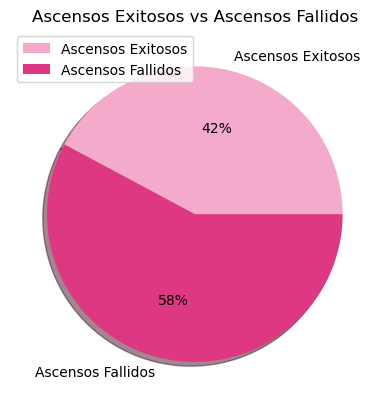

In [ ]:
valores = [ascensos_exitosos, ascensos_fallidos]
etiquetas = ["Ascensos Exitosos", "Ascensos Fallidos"]
colores = ["#f3aacb", "#df3883"]

plt.pie(x=valores, labels=etiquetas, autopct="%1.0f%%", shadow=True, colors=colores)
plt.title("Ascensos Exitosos vs Ascensos Fallidos")
plt.legend()
plt.show()

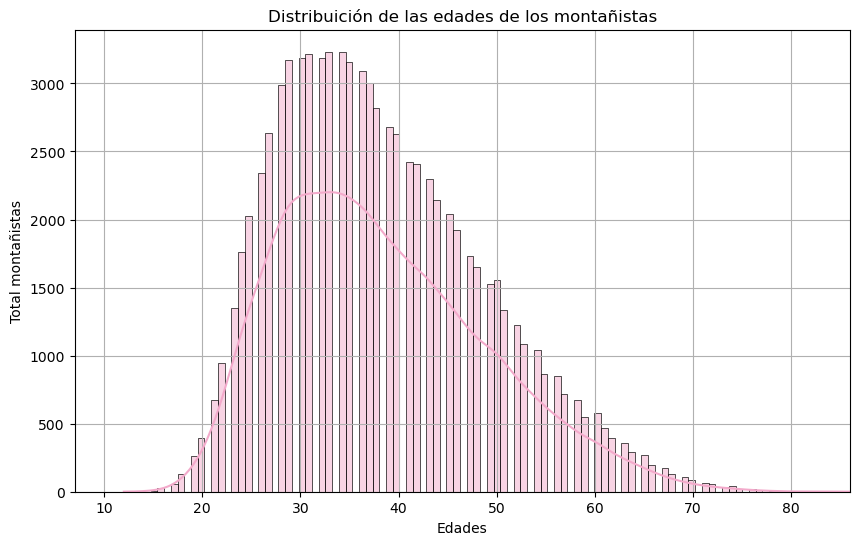

count    83590.000000
mean        38.290358
std         10.579652
min         12.000000
25%         30.000000
50%         37.000000
75%         45.000000
max         86.000000
Name: age, dtype: float64

In [ ]:
edad = clean_df["age"]

plt.figure(figsize=(10,6))
sns.histplot(data=clean_df, x=edad, kde=True, color="#f3aacb")
plt.title("Distribuición de las edades de los montañistas")
plt.xlabel("Edades")
plt.ylabel("Total montañistas")
plt.grid(True)
plt.xlim(7,86)
plt.show()

edad.describe()

In [ ]:
tabla = (clean_df.groupby(["season", "msuccess"], observed=False).size().unstack(fill_value=0).rename(columns={True: "Exitosos", False: "Fallidos"}).sort_index())

tabla["Total"] = tabla.sum(axis=1)
tabla["% Exitosos"] = (tabla["Exitosos"] / tabla["Total"] * 100).round(1)
tabla["% Fallidos"] = (tabla["Fallidos"] / tabla["Total"] * 100).round(1)

print("Podemos ver los porcentajes de Ascensos exitosos y Ascensos Fallidos por estaciones")
display(tabla)

Podemos ver los porcentajes de Ascensos exitosos y Ascensos Fallidos por estaciones


msuccess,Fallidos,Exitosos,Total,% Exitosos,% Fallidos
season,,,,,
Autumn,23923,15606,39529,39.5,60.5
Spring,22304,18987,41291,46.0,54.0
Summer,469,176,645,27.3,72.7
Winter,1634,491,2125,23.1,76.9


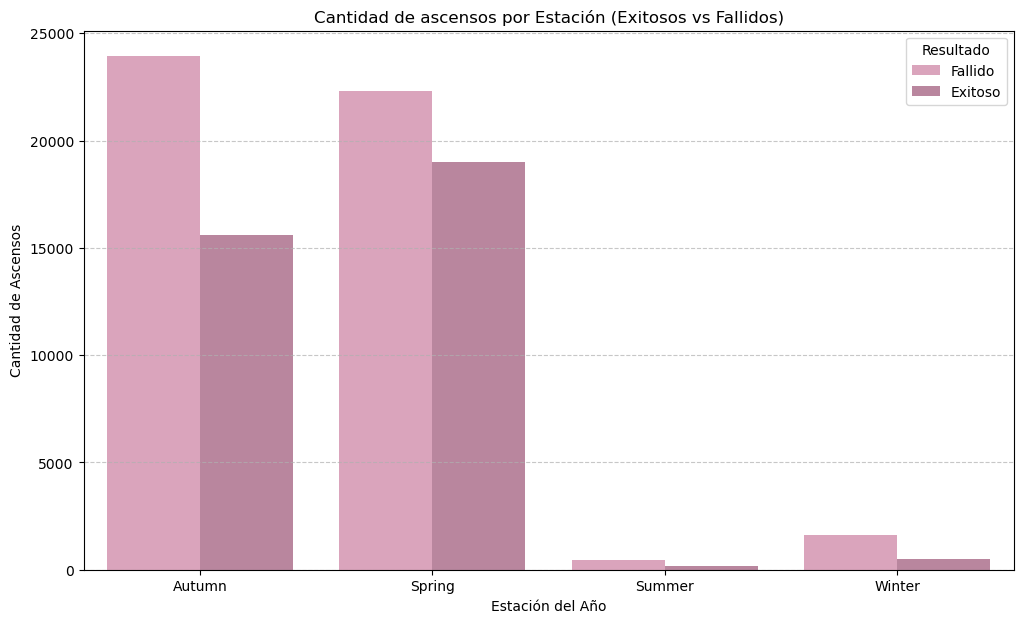

In [ ]:
colores = ["#e39bbb", "#c27d9d"]
plt.figure(figsize=(12,7))
sns.countplot(data=clean_df, x="season",hue="msuccess", palette=colores)
plt.title("Cantidad de ascensos por Estación (Exitosos vs Fallidos)")
plt.xlabel("Estación del Año")
plt.ylabel("Cantidad de Ascensos")
plt.grid(axis="y", linestyle = "--", alpha=0.7)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Fallido', 'Exitoso'], title='Resultado')
plt.show()

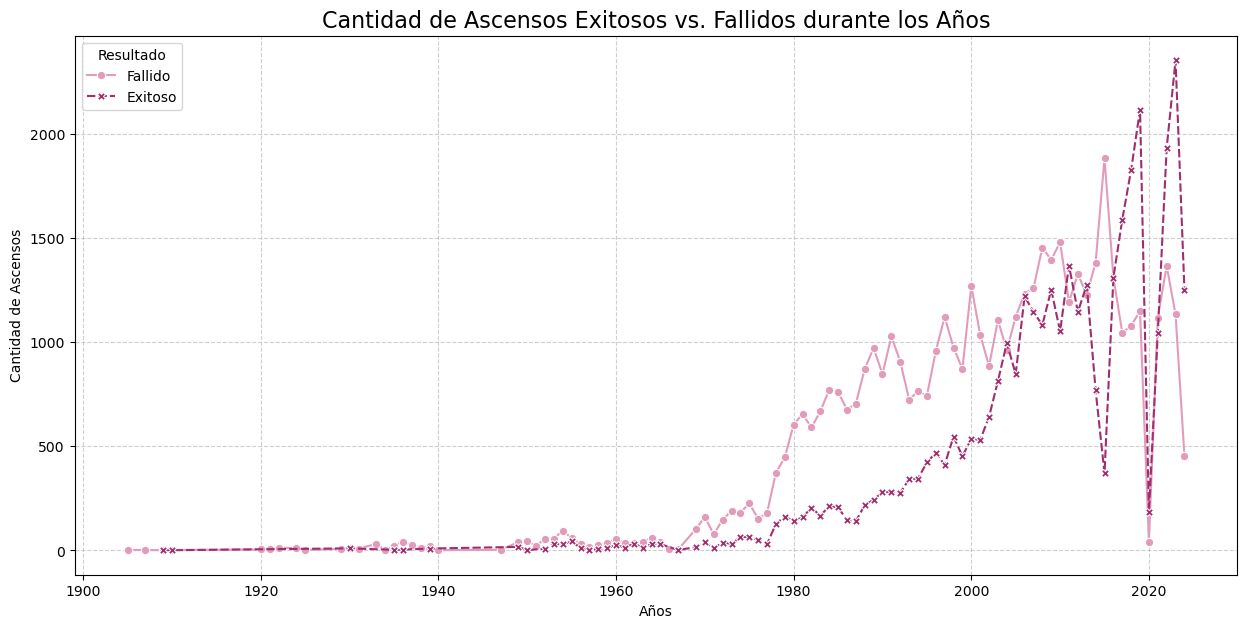

In [ ]:
#Hacemos el conteo por años
años = clean_df.groupby(['year', 'msuccess']).size().reset_index(name='cantidad')
#Etiquetamos para ascensos Exitosos y Fallidos
años['resultado'] = años['msuccess'].map({True: 'Exitoso', False: 'Fallido'})
colores = {'Fallido': "#e39bbb", 'Exitoso': "#a22d6e"}

plt.figure(figsize=(15, 7)) 
sns.lineplot(data=años, x='year', y='cantidad', hue='resultado', palette=colores, style='resultado',markers=True)
plt.title("Cantidad de Ascensos Exitosos vs. Fallidos durante los Años", fontsize=16)
plt.xlabel('Años')
plt.ylabel('Cantidad de Ascensos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Resultado')
plt.show()

In [ ]:
#Agarramos las columnas que son de las montañas/cumbres y las de fallido y exitosos
cumbres = ['peakid', 'pkname', 'heightm', 'success_exp', 'failed_exp', 'peak_success_p']
#Quitamos los ID duplicados de las cumbres y creamos una copia
df_cumbres = clean_df[cumbres].drop_duplicates(subset=['peakid']).copy()
#Sacamos el total de las expediciones que tenemos
df_cumbres['total_expediciones'] = df_cumbres['success_exp'] + df_cumbres['failed_exp']

df_cumbres.head()


,peakid,pkname,heightm,success_exp,failed_exp,peak_success_p,total_expediciones
0,AMAD,Ama Dablam,6814,1123,453,71.256345,1576
29,BARU,Baruntse,7152,131,204,39.104478,335
52,CHOY,Cho Oyu,8188,861,498,63.355408,1359
176,EVER,Everest,8849,1495,852,63.698338,2347
584,GANC,Ganchenpo,6378,8,16,33.333333,24


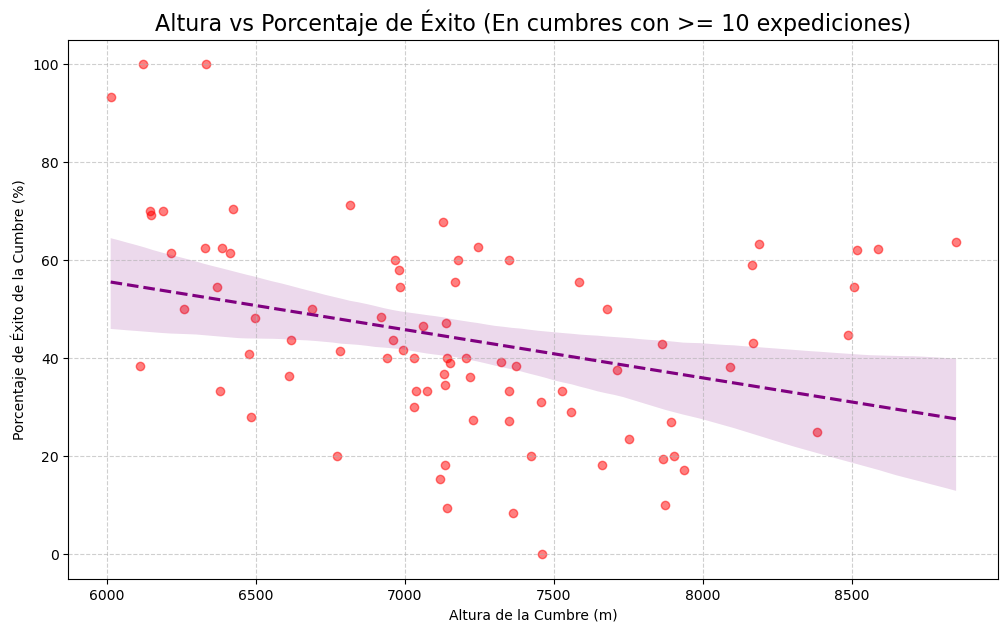

In [ ]:
#Hacemos el filtro con las condiciones que nos piden.
df_cumbres_filtro = df_cumbres[df_cumbres['total_expediciones'] >= 10].copy()

plt.figure(figsize=(12, 7))

sns.regplot(data=df_cumbres_filtro,x='heightm',y='peak_success_p',line_kws={"color": "purple", "linestyle": "--"}, scatter_kws={"alpha": 0.5, "color":"red"})               

plt.title('Altura vs Porcentaje de Éxito (En cumbres con >= 10 expediciones)', fontsize=16)
plt.xlabel('Altura de la Cumbre (m)')
plt.ylabel('Porcentaje de Éxito de la Cumbre (%)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## 5. Predictor (2.5 puntos)

Ahora veremos si la información que tenemos nos permite predecir el éxito de un ascenso por alguna persona en particular. Primero, defina su **X** (matriz de atributos) e **y** (etiqueta a predecir) de la siguiente manera:

* **X**: `age`, `sex`, `citizen`, `season`, `heightm`, `year`, `success_exp`, `failed_exp`
* **y**: `msuccess`

Luego, realice los pasos a continuación:

**5.1 Codificación y normalización (1 pto)**
* Codifique todas las columnas categóricas, de manera que su matriz **X** solo tenga valores numéricos.
* Divida sus datos en sets de entrenamiento y testeo. Use una división de 70-30.
* Normalice sus matrices de atributos. Justifique su método de normalización.

**5.2 Creación y entrenamiento de modelos (1 pto)**
* Cree y entrene los siguientes modelos:
    * Un clasificador KNN
    * Un árbol de decisión
    * Un clasificador de regresión logística
    * Un clasificador random forest **(Opcional)**

    Explique qué hiperparámetros utilizó para la creación de cada uno de ellos y qué valores le asignó.

* Finalmente, evalúe todos sus modelos con el set de testeo. Para cada uno, muestre
    * Accuracy
    * Precisión
    * Recall
    * Matriz de confusión

**5.3 Análisis de resultados (0.5 pts)**

Interprete, analice y comente sus resultados. 
* ¿Qué tendencias puede observar? ¿Se diferencian de alguna forma las predicciones entre un modelo y otro? 
* ¿Fue posible construir un predictor efectivo? Justique.



In [ ]:
columnas= ['age', 'sex', 'citizen', 'season', 'heightm', 'year', 'success_exp', 'failed_exp']

X = clean_df[columnas]
y = clean_df["msuccess"]

#Hacemos división de datos (70-30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
#Hacemos la normalización para las columnas numéricas con el escalador StandarScaler
columnas_numericas = ["age","heightm","year","success_exp","failed_exp"]
#Primero creamos el escalador 
escalador = StandardScaler()
#Ajustamos (fit) el escalador con los datos de entrenamiento
escalador.fit(X_train[columnas_numericas])

X_train_escalador_numerico = escalador.transform(X_train[columnas_numericas])
X_test_escalador_numerico = escalador.transform(X_test[columnas_numericas])

#Ahora hacemos la codificación de las columnas categóricas
columnas_categoricas = ["sex", "citizen", "season"]
#Creamos el codificador 
codificador = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
codificador.fit(X_train[columnas_categoricas])
#Hacemos la transformación 
X_train_codificador_categorico = codificador.transform(X_train[columnas_categoricas])
X_test_codificador_categorico = codificador.transform(X_test[columnas_categoricas])

#Unimos todo
X_train_procesado = np.hstack((X_train_escalador_numerico, X_train_codificador_categorico))
X_test_procesado = np.hstack((X_test_escalador_numerico, X_test_codificador_categorico))



### Modelo kNN

Accuracy: 0.7115
Presición: 0.6638
Recall: 0.6344

Reporte de Clasificación:
              precision    recall  f1-score   support

     Fallido       0.74      0.77      0.76     14544
     Exitoso       0.66      0.63      0.65     10533

    accuracy                           0.71     25077
   macro avg       0.70      0.70      0.70     25077
weighted avg       0.71      0.71      0.71     25077



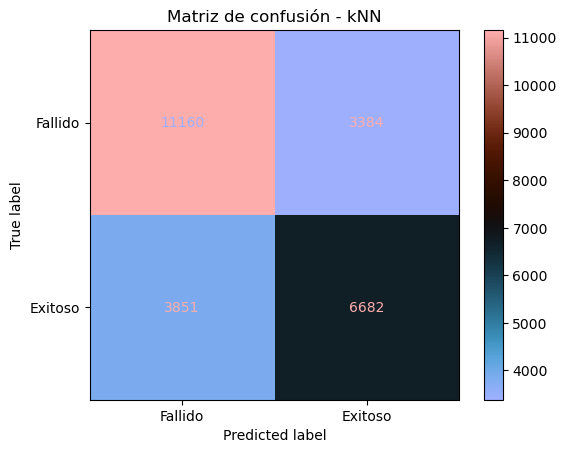

In [ ]:
#Entrenamos el modelo knn
#El hiperparámetro utilizado fue n_neighbors y le asignamos el valor 5(le asigne el valor 5 ya que es punto de partida común y es balanceado)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_procesado, y_train)

y_prediccion_knn = knn.predict(X_test_procesado)
#Métricas
accuracy_knn = accuracy_score(y_test, y_prediccion_knn)
presicion_knn = precision_score(y_test, y_prediccion_knn, pos_label=True)
recall_knn = recall_score(y_test, y_prediccion_knn, pos_label=True)

print(f"Accuracy: {accuracy_knn:.4f}\nPresición: {presicion_knn:.4f}\nRecall: {recall_knn:.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_prediccion_knn, target_names=['Fallido', 'Exitoso']))
#Matriz de Confusión
#Hacemos la matriz cruda
confusion_m = confusion_matrix(y_test, y_prediccion_knn)
#Preparamos el visualizador Knn
visualizador_knn = ConfusionMatrixDisplay(confusion_matrix=confusion_m, display_labels=["Fallido", "Exitoso"])

visualizador_knn.plot(cmap="berlin")
plt.title("Matriz de confusión - kNN")
plt.show()





### Árbol de desición

Accuracy: 0.7363
Presición: 0.7020
Recall: 0.6467

Reporte de Clasificación:
              precision    recall  f1-score   support

     Fallido       0.76      0.80      0.78     14544
     Exitoso       0.70      0.65      0.67     10533

    accuracy                           0.74     25077
   macro avg       0.73      0.72      0.73     25077
weighted avg       0.73      0.74      0.73     25077



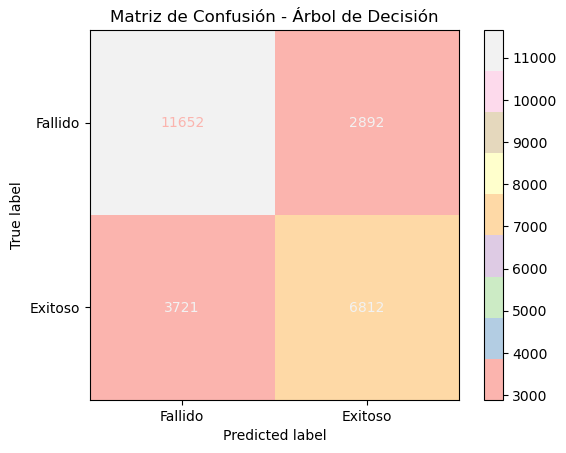

In [ ]:
#Definimos los Hiperparámetros
#Nuestro Hiperparámetro "max_depth"(Profundidad máxima) le ponemos de límite 10 es para que depués de 10 niveles de preguntas se detenga
#y así evitamos el Overfitting y obliga al modelo a encontrar sus 10 patrones más fuertes
tree  = DecisionTreeClassifier(max_depth=10)
#Entrenamos el modelo
tree.fit(X_train_procesado, y_train)
#Obtenemos las predicciones
y_prediccion_tree = tree.predict(X_test_procesado)

#Métricas
accuracy_tree = accuracy_score(y_test, y_prediccion_tree)
presicion_tree = precision_score(y_test, y_prediccion_tree, pos_label=True)
recall_tree = recall_score(y_test, y_prediccion_tree, pos_label=True)

print(f"Accuracy: {accuracy_tree:.4f}\nPresición: {presicion_tree:.4f}\nRecall: {recall_tree:.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_prediccion_tree, target_names=['Fallido', 'Exitoso']))
#Creamos el visualizador
cm_tree = confusion_matrix(y_test, y_prediccion_tree)
visualizador_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['Fallido', 'Exitoso'])
visualizador_tree.plot(cmap="Pastel1")
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.show()

### Regresión logística

Accuracy: 0.6988
Presición: 0.6775
Recall: 0.5400

Reporte de Clasificación:
              precision    recall  f1-score   support

     Fallido       0.71      0.81      0.76     14544
     Exitoso       0.68      0.54      0.60     10533

    accuracy                           0.70     25077
   macro avg       0.69      0.68      0.68     25077
weighted avg       0.70      0.70      0.69     25077



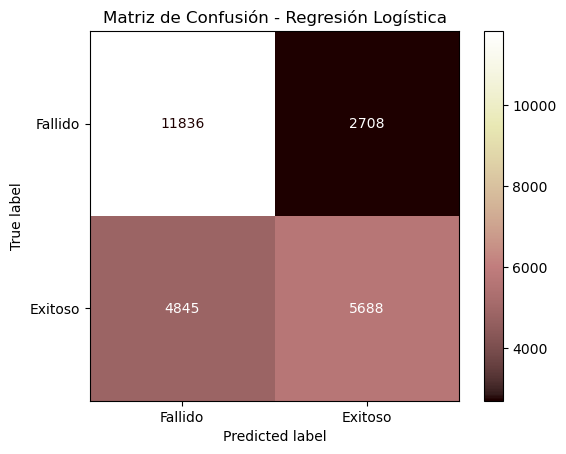

In [ ]:
#Definimos el hiperparámetro "Max_iter" le puse 1000 ya que es un buen rango para que nos entregue la solución optima, ya que menos podrían no ser suficientes para encontrar la mejor solución
# y más de mil es inneccesario ya que el modelo puede ser empezar a converger en el mismo punto al darle varias repeticiones
regresion_logistica = LogisticRegression(max_iter=1000)
#Entrenamos al modelo
regresion_logistica.fit(X_train_procesado, y_train)
#Predecimos
y_prediccion_rl = regresion_logistica.predict(X_test_procesado)

#Métricas
accuracy_rl = accuracy_score(y_test, y_prediccion_rl)
presicion_rl = precision_score(y_test, y_prediccion_rl, pos_label=True)
recall_rl = recall_score(y_test, y_prediccion_rl, pos_label=True)

print(f"Accuracy: {accuracy_rl:.4f}\nPresición: {presicion_rl:.4f}\nRecall: {recall_rl:.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_prediccion_rl, target_names=['Fallido', 'Exitoso']))

#Creamos la matriz de Confusión
cm_rl = confusion_matrix(y_test, y_prediccion_rl)
#Creamos el visualizador
visualizador_rl = ConfusionMatrixDisplay(confusion_matrix=cm_rl, display_labels=["Fallido", "Exitoso"])
visualizador_rl.plot(cmap="pink")
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

### Random Forest

Accuracy: 0.7448
Precision ('Exitoso'): 0.7037
Recall ('Exitoso'): 0.6779

Reporte de Clasificación:
              precision    recall  f1-score   support

     Fallido       0.77      0.79      0.78     14544
     Exitoso       0.70      0.68      0.69     10533

    accuracy                           0.74     25077
   macro avg       0.74      0.74      0.74     25077
weighted avg       0.74      0.74      0.74     25077



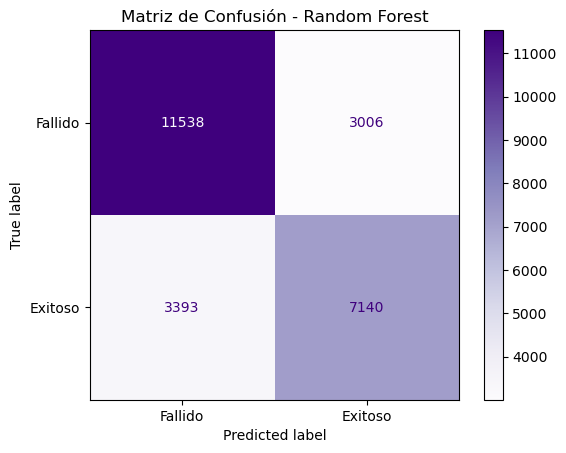

In [ ]:
#Creamos el modelo Random Forest, definimos el hiperparámetro que es n_estimators elegí el 100 ya que es el mejor para el equilibrio entre rendimiento y velocidad
#Adémas busque que valor era mejor y encontre que decian que el 100 era el mejor para esto ("https://qu4nt.github.io/sklearn-doc-es/modules/generated/sklearn.ensemble.RandomForestClassifier.html")
randomforest = RandomForestClassifier(n_estimators=100)

#Entrenamos el modelo
randomforest.fit(X_train_procesado, y_train)
#Creamos la predicción
y_prediccion_rf = randomforest.predict(X_test_procesado)

# Métricas solicitadas
acc_rf = accuracy_score(y_test, y_prediccion_rf)
precision_rf = precision_score(y_test, y_prediccion_rf, pos_label=True)
recall_rf = recall_score(y_test, y_prediccion_rf, pos_label=True)

print(f"Accuracy: {acc_rf:.4f}")
print(f"Precision ('Exitoso'): {precision_rf:.4f}")
print(f"Recall ('Exitoso'): {recall_rf:.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_prediccion_rf, target_names=['Fallido', 'Exitoso']))

# Creamos la Matriz de Confusión
cm_rf = confusion_matrix(y_test, y_prediccion_rf)

# Preparamos el visualizador
visualizador_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Fallido', 'Exitoso'])
visualizador_rf.plot(cmap='Purples')
plt.title("Matriz de Confusión - Random Forest")
plt.show()

